In [2]:
from general_utils import smart_read_csv, find_ephys_sessions
metadata=smart_read_csv('/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv')

In [3]:
metadata

,session_id,unit_index,brain_region,ccf_location,device_name
0,753124_2024-12-10_17-24-56,9,NaN,"{'best_electrode': 1, 'shank': 0, 'probe': 'Pr...",ProbeA
1,753124_2024-12-10_17-24-56,14,NaN,"{'best_electrode': 7, 'shank': 0, 'probe': 'Pr...",ProbeA
2,753124_2024-12-10_17-24-56,17,NaN,"{'best_electrode': 6, 'shank': 0, 'probe': 'Pr...",ProbeA
3,753124_2024-12-10_17-24-56,20,NaN,"{'best_electrode': 6, 'shank': 0, 'probe': 'Pr...",ProbeA
4,753124_2024-12-10_17-24-56,26,NaN,"{'best_electrode': 10, 'shank': 0, 'probe': 'P...",ProbeA
...,...,...,...,...,...
24419,795396_2025-09-20_13-11-19,2880,NaN,"{'best_electrode': 22, 'shank': 3, 'probe': 'P...",ProbeD
24420,795396_2025-09-20_13-11-19,2887,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD
24421,795396_2025-09-20_13-11-19,2888,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD
24422,795396_2025-09-20_13-11-19,2889,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD


In [3]:
import numpy as np
from ephys_dimension_reduction_CD import coding_direction_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions

sessions = find_ephys_sessions()
failed_sessions = []

binsize = "0.2"
align = "go_cue"
projection_time_window = None     # None => full peri-event time
two_fold_cv = True                # use the swap split as well
norm_mode = "divide_sqrtN"        # {"none","divide_sqrtN","unit_variance_fit","zscore_fit"}

time_windows = [[0.3, 2], [-1, 0]]
trial_types = ["right_choice_trials","left_choice_trials"]
#trial_types = ["rewarded_trials","unrewarded_trials"]

metadata=smart_read_csv('/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv')
for session in sessions[2]:
    try:
        psth_da = load_zarr(f"/root/capsule/scratch/psth_results/{session}_{binsize}s.zarr")
        df = smart_read_csv(f"/root/capsule/scratch/behavior_summary/behavior_summary-{session}.csv")

        # Pull trial-id arrays and clean up (drop NaN, cast to int)
        def _clean_ids(x):
            arr = np.asarray(x[0])
            arr = arr[~np.isnan(arr)] if arr.dtype.kind in {"f"} else arr
            return arr.astype(int)

        typeA_ids = _clean_ids(df[trial_types[0]])
        typeB_ids = _clean_ids(df[trial_types[1]])

        for time_window in time_windows:
            save_path = (
                f"/root/capsule/scratch/CD_results/CD_{session}_{trial_types[0]}_{trial_types[1]}"
                f"_timewindow_{time_window[0]}_{time_window[1]}.zarr"
            )

            out = coding_direction_from_psth(
                psth_da=psth_da,
                trial_ids_typeA=typeA_ids,
                trial_ids_typeB=typeB_ids,
                align=align,
                time_window=tuple(time_window),
                projection_time_window=projection_time_window,
                random_state=0,
                two_fold_cv=two_fold_cv,
                norm_mode=norm_mode,
                save_path=save_path,
                save_format="zarr",
                overwrite=True,
            )

            # Prefer the returned path if the function decides/changes it
            print(f"Finished: {out.get('saved_to', save_path)}")

    except Exception as e:
        print(f"❌ Error in session {session}: {e}")
        failed_sessions.append(session)

print("\nAll sessions done.")
if failed_sessions:
    print("Failed sessions:")
    for s in failed_sessions:
        print(f" - {s}")
else:
    print("No errors 🎉")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Literal
from scipy.ndimage import gaussian_filter1d, uniform_filter1d


def plot_cd_window_distribution(
    time: np.ndarray,
    trace_A: np.ndarray,   # shape: (nA, T)
    trace_B: np.ndarray,   # shape: (nB, T)
    *,
    window: Tuple[float, float],
    kind: Literal["hist", "violin", "box"] = "hist",
    bins: int = 30,
    hist_overlay: bool = True,     # for kind="hist": overlay vs. side-by-side
    density: bool = True,          # histogram density
    figsize: Tuple[int, int] = (6, 4),
    labels: Tuple[str, str] = ("Type A", "Type B"),
    title: Optional[str] = None,
    xlabel: str = "Mean projection in window",
    ylabel: Optional[str] = None,  # defaults per-kind
    return_values: bool = False,   # if True, also return the per-trial means
):
    """
    For each trial, average its CD trace over `window=(t0, t1)` and plot A vs B distributions.

    Parameters
    ----------
    time : (T,)
        Time vector (seconds).
    trace_A, trace_B : (n_trials, T)
        Time-resolved projections per trial for the two classes.
    window : (t0, t1)
        Time window in *seconds* over which to average each trial's trace.
    kind : {'hist','violin','box'}
        Which distribution plot to draw.
    bins : int
        Histogram bins (for kind='hist').
    hist_overlay : bool
        Overlay the two histograms (True) or draw them side-by-side (False).
    density : bool
        Normalize histogram to a probability density.
    figsize : (w, h)
        Figure size.
    labels : (label_A, label_B)
        Legend/axis labels for the two classes.
    title : str or None
        Optional figure title.
    xlabel, ylabel : str or None
        Axis labels. If ylabel is None, a sensible default is chosen per plot type.
    return_values : bool
        If True, returns (means_A, means_B).

    Notes
    -----
    - Trials with all-NaN values in the selected window are dropped automatically.
    - If the window extends beyond the time range, it is clipped to valid samples.
    """
    t0, t1 = window
    if t0 > t1:
        t0, t1 = t1, t0

    # Build mask for the requested window; clip to valid time range
    mask = (time >= t0) & (time < t1)
    if not np.any(mask):
        # If nothing selected, try inclusive end if t1 equals last sample
        mask = (time >= t0) & (time <= t1)
    if not np.any(mask):
        raise ValueError(f"Window {window} selects no samples within time range [{time.min()}, {time.max()}].")

    # Compute per-trial means over the window (ignore NaNs)
    def _per_trial_mean(tr):
        # tr: (n_trials, T)
        sub = tr[:, mask]
        means = np.nanmean(sub, axis=1)
        # Drop all-NaN trials (mean becomes NaN)
        return means[np.isfinite(means)]

    means_A = _per_trial_mean(trace_A)
    means_B = _per_trial_mean(trace_B)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    if kind == "hist":
        if hist_overlay:
            ax.hist(means_A, bins=bins, density=density, alpha=0.5, label=labels[0])
            ax.hist(means_B, bins=bins, density=density, alpha=0.5, label=labels[1])
        else:
            # side by side using two axes sharing y
            ax.hist(means_A, bins=bins, density=density, alpha=0.7, label=labels[0])
            ax.hist(means_B, bins=bins, density=density, alpha=0.7, label=labels[1])
        ax.set_ylabel("Density" if density else "Count" if ylabel is None else ylabel)

    elif kind == "violin":
        parts = ax.violinplot([means_A, means_B], showmeans=True, showextrema=True, widths=0.8)
        ax.set_xticks([1, 2], labels)
        ax.set_ylabel("Mean projection" if ylabel is None else ylabel)

        # Optional: faint scatter of individual points (jitter)
        xA = np.random.uniform(0.85, 1.15, size=means_A.size)
        xB = np.random.uniform(1.85, 2.15, size=means_B.size)
        ax.scatter(xA, means_A, alpha=0.4, s=10)
        ax.scatter(xB, means_B, alpha=0.4, s=10)

    elif kind == "box":
        ax.boxplot([means_A, means_B], widths=0.6, showmeans=True)
        ax.set_xticks([1, 2], labels)
        ax.set_ylabel("Mean projection" if ylabel is None else ylabel)

        # Optional: faint scatter of individual points (jitter)
        xA = np.random.uniform(0.85, 1.15, size=means_A.size)
        xB = np.random.uniform(1.85, 2.15, size=means_B.size)
        ax.scatter(xA, means_A, alpha=0.4, s=10)
        ax.scatter(xB, means_B, alpha=0.4, s=10)

    else:
        raise ValueError("kind must be one of {'hist','violin','box'}")

    ax.set_xlabel(xlabel)
    if kind == "hist":
        ax.legend(frameon=False)
    if title:
        ax.set_title(title + f"  (window: {t0:.3f}–{t1:.3f}s)")
    else:
        ax.set_title(f"Distribution of trial means (window: {t0:.3f}–{t1:.3f}s)")
    plt.tight_layout()
    plt.show()

    if return_values:
        return means_A, means_B


def plot_cd_projection(
    time: np.ndarray,
    trace_A: np.ndarray,
    trace_B: np.ndarray,
    *,
    average: bool = True,
    sem: bool = True,
    smooth: Optional[float] = None,
    smooth_mode: Literal["gaussian", "moving"] = "gaussian",
    dt: Optional[float] = None,
    edge_handling: Literal["reflect", "nearest", "mirror", "wrap", "none"] = "reflect",
    labels: Tuple[str, str] = ("Type A", "Type B"),
    colors: Tuple[str, str] = ("#1f77b4", "#d62728"),
    figsize: Tuple[int, int] = (6, 4),
    alpha_single: float = 0.15,
    linewidth_mean: float = 2.0,
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
    title: Optional[str] = None,
    xlabel: str = "Time (s)",
    ylabel: str = "Projection along CD",
) -> None:
    """
    Plot coding-direction projection traces for two trial types (A vs B),
    with optional temporal smoothing and robust edge handling.

    Parameters
    ----------
    smooth : float or None
        If >0, smoothing window. Interpreted in *seconds* if `dt` is provided,
        otherwise in *samples*.
    smooth_mode : {'gaussian','moving'}
        Gaussian kernel (softer) or moving average (boxcar).
    dt : float or None
        Sample spacing (sec). Needed only if `smooth` is in seconds.
    edge_handling : {'reflect','nearest','mirror','wrap','none'}
        How to treat edges when smoothing. 'reflect' (default) avoids boundary artefacts.
        If 'none', no padding is used; instead the plot is trimmed to the valid region.
    """
    def _kernel_pts():
        if smooth is None or smooth <= 0:
            return 0
        return max(1, int(round((smooth if dt is None else smooth / dt))))

    def _smooth_traces(tr: np.ndarray) -> Tuple[np.ndarray, Optional[slice]]:
        k = _kernel_pts()
        if k <= 1:
            return tr, None

        if smooth_mode == "gaussian":
            # Use reflect to avoid ramps/flattening at the ends
            tr_sm = gaussian_filter1d(tr, sigma=k, axis=-1, mode=("nearest" if edge_handling=="none" else edge_handling), truncate=3.0)
            if edge_handling == "none":
                # Trim ~3*sigma samples from both ends (valid region)
                trim = int(3.0 * k)
                sl = slice(trim, tr.shape[-1]-trim)
                tr_sm = tr_sm[..., sl]
                return tr_sm, sl
            return tr_sm, None

        elif smooth_mode == "moving":
            if edge_handling == "none":
                # Valid-only convolution: use cumulative-sum trick and trim ends
                w = k
                # boxcar via cumulative sum (valid window only)
                def _boxcar_valid(x):
                    c = np.cumsum(np.pad(x, (1,0), mode="constant"))
                    y = (c[w:] - c[:-w]) / w
                    return y
                sm = np.apply_along_axis(_boxcar_valid, -1, tr)
                sl = slice(k//2, tr.shape[-1] - (k - 1 - k//2))
                return sm, sl
            else:
                tr_sm = uniform_filter1d(tr, size=k, axis=-1, mode=edge_handling)
                return tr_sm, None
        else:
            raise ValueError("smooth_mode must be 'gaussian' or 'moving'.")

    # Smooth A/B (and get any trimming slices if edge_handling=='none')
    trace_A_sm, slA = _smooth_traces(trace_A)
    trace_B_sm, slB = _smooth_traces(trace_B)

    # If we trimmed, align time to the valid region
    time_plot = time
    if slA is not None or slB is not None:
        # Use intersection of valid slices
        def _to_slice(s, n):
            return s if s is not None else slice(0, n)
        n = time.shape[0]
        sA = _to_slice(slA, n); sB = _to_slice(slB, n)
        start = max(sA.start, sB.start)
        stop  = min(sA.stop,  sB.stop)
        sl = slice(start, stop)
        trace_A_sm = trace_A_sm[..., slA.start - start: slA.start - start + (stop-start)]
        trace_B_sm = trace_B_sm[..., slB.start - start: slB.start - start + (stop-start)]
        time_plot = time[sl]

    fig, ax = plt.subplots(figsize=figsize)

    def _plot_group(traces, color, label):
        if average:
            mean = np.nanmean(traces, axis=0)
            if sem:
                err = np.nanstd(traces, axis=0) / np.sqrt(max(1, traces.shape[0]))
                ax.fill_between(time_plot, mean - err, mean + err, color=color, alpha=0.25, lw=0)
            ax.plot(time_plot, mean, color=color, lw=linewidth_mean, label=label)
        else:
            # faint single trials + thick mean on top
            for tr in traces:
                ax.plot(time_plot, tr, color=color, alpha=alpha_single, lw=1.0)
            ax.plot(time_plot, np.nanmean(traces, axis=0), color=color, lw=linewidth_mean, label=label)

    _plot_group(trace_A_sm, colors[0], labels[0])
    _plot_group(trace_B_sm, colors[1], labels[1])

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    if title: ax.set_title(title)
    ax.legend(frameon=False)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import xarray as xr
import numpy as np
import re
import pandas as pd
from general_utils import smart_read_csv
    
base_dir='/root/capsule/scratch/'
session='ecephys_764787_2024-12-13_18-27-42_sorted_2024-12-17_18-31-24'
#session='ecephys_753126_2024-10-15_12-20-35_sorted_2024-11-09_19-47-57'
end_with='_right_choice_trials_left_choice_trials_timewindow_-1_0'

df = smart_read_csv(f"{base_dir}/behavior_summary-{session}.csv")
ds = xr.open_zarr(f"{base_dir}/CD_{session}{end_with}.zarr", consolidated=False)


import numpy as np

time = ds["time"].values

# --- Load and clean trial IDs ---
switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)
switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)

trial_id_test_A = np.asarray(ds["trial_id_test_A"].values, dtype=int)
trial_id_test_B = np.asarray(ds["trial_id_test_B"].values, dtype=int)
trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

proj_train_A = ds["projection_trace_train_A"].values
proj_train_B = ds["projection_trace_train_B"].values
proj_test_A = ds["projection_trace_test_A"].values
proj_test_B = ds["projection_trace_test_B"].values

# --- Helper function ---
def select_traces_by_switch(proj, trial_ids, switch_ids):
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

# --- Train set ---
proj_train_A_LR, trial_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
proj_train_A_RL, trial_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

proj_train_B_LR, trial_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
proj_train_B_RL, trial_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

# --- Test set ---
proj_test_A_LR, trial_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
proj_test_A_RL, trial_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

proj_test_B_LR, trial_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
proj_test_B_RL, trial_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

# --- Summary printout ---
print("Train A  (LR / RL):", proj_train_A_LR.shape[0], "/", proj_train_A_RL.shape[0])
print("Train B  (LR / RL):", proj_train_B_LR.shape[0], "/", proj_train_B_RL.shape[0])
print("Test  A  (LR / RL):", proj_test_A_LR.shape[0], "/", proj_test_A_RL.shape[0])
print("Test  B  (LR / RL):", proj_test_B_LR.shape[0], "/", proj_test_B_RL.shape[0])



proj_A=proj_train_A
proj_B=proj_train_B
# If your time vector is in seconds:
dt = np.mean(np.diff(time))

# Plot smoothed mean ± SEM (Gaussian, 100 ms)
plot_cd_projection(
    time, proj_A, proj_B,
    average=True, sem=True,
    smooth=0.1, dt=dt, smooth_mode="gaussian",
    title="Coding Direction Projection (Smoothed)"
)

# Or plot all single-trial traces with mild moving average smoothing
plot_cd_projection(
    time, proj_A, proj_B,
    average=False,
    smooth=5, smooth_mode="moving",   # smooth 10 points
    title="Single-Trial CD Projections (Smoothed)"
)


In [ ]:
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
from general_utils import smart_read_csv

# --- Config ---
base_dir = "/root/capsule/scratch/"
# Pattern of your Zarr outputs (example file shown in your message)
zarr_glob = os.path.join(base_dir, "CD_*.zarr")

# Regex to recover the base session name used by the behavior CSV
# e.g. CD_ecephys_753125_..._timewindow_-1_0.zarr  ->  ecephys_753125_..._sorted_YYYY-MM-DD_HH-MM-SS
#session_re = re.compile(r"^CD_(?P<session>.+?)_right_choice_trials_left_choice_trials_timewindow_-1_0\.zarr$")
session_re = re.compile(r"^CD_(?P<session>.+?)_rewarded_trials_unrewarded_trials_timewindow_0.3_2\.zarr$")
#session_re = re.compile(r"^CD_(?P<session>.+?)_rewarded_trials_unrewarded_trials_timewindow_-1_0\.zarr$")
#session_re = re.compile(r"^CD_(?P<session>.+?)_right_choice_trials_left_choice_trials_timewindow_-1_0\.zarr$")
distribution_window=(0.3,2)
def select_traces_by_switch(proj, trial_ids, switch_ids):
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

# Optional: collect a summary table across all sessions
summ_rows = []

for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)
    m = session_re.match(zname)
    if not m:
        print(f"[skip] filename pattern not recognized: {zname}")
        continue

    # Behavior CSV is named: behavior_summary-<session>.csv
    session_name = m.group("session")
    beh_csv = os.path.join(base_dir, f"behavior_summary-{session_name}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {zname} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print(f"Zarr: {zpath}")
    print(f"CSV : {beh_csv}")

    # --- Load behavior + CD dataset ---
    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zpath, consolidated=False)

    # --- Pull time + projections + IDs ---
    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan

    trial_id_test_A  = np.asarray(ds["trial_id_test_A"].values, dtype=int)
    trial_id_test_B  = np.asarray(ds["trial_id_test_B"].values, dtype=int)
    trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
    trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

    proj_train_A = ds["projection_trace_train_A"].values
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # --- Switch trial IDs from behavior ---
    # Assumes df["switch_LR_trials"][0] & df["switch_RL_trials"][0] are arrays/list-like
    switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)
    switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)

    # --- Select subsets by switch type ---
    # Train
    proj_train_A_LR, trial_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
    proj_train_A_RL, trial_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

    proj_train_B_LR, trial_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
    proj_train_B_RL, trial_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

    # Test
    proj_test_A_LR, trial_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
    proj_test_A_RL, trial_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

    proj_test_B_LR, trial_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
    proj_test_B_RL, trial_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

    # --- Summary printout per session ---
    print("Train A  (LR / RL):", proj_train_A_LR.shape[0], "/", proj_train_A_RL.shape[0])
    print("Train B  (LR / RL):", proj_train_B_LR.shape[0], "/", proj_train_B_RL.shape[0])
    print("Test  A  (LR / RL):", proj_test_A_LR.shape[0], "/", proj_test_A_RL.shape[0])
    print("Test  B  (LR / RL):", proj_test_B_LR.shape[0], "/", proj_test_B_RL.shape[0])

    summ_rows.append({
        "session": session_name,
        "train_A_LR_n": int(proj_train_A_LR.shape[0]),
        "train_A_RL_n": int(proj_train_A_RL.shape[0]),
        "train_B_LR_n": int(proj_train_B_LR.shape[0]),
        "train_B_RL_n": int(proj_train_B_RL.shape[0]),
        "test_A_LR_n": int(proj_test_A_LR.shape[0]),
        "test_A_RL_n": int(proj_test_A_RL.shape[0]),
        "test_B_LR_n": int(proj_test_B_LR.shape[0]),
        "test_B_RL_n": int(proj_test_B_RL.shape[0]),
    })

    # --- Plotting ---
    # Use TRAIN by default like your snippet; change to *_test_* if desired
    try:
        # Smoothed mean ± SEM (Gaussian, 100 ms)
        plot_cd_projection(
            time,
            proj_train_A, proj_train_B,
            average=True, sem=True,
            smooth=0.1, dt=dt, smooth_mode="gaussian",
            title=f"[{session_name}] Coding Direction Projection (Smoothed)"
        )

        # Single-trial traces with mild moving average smoothing
        plot_cd_projection(
            time,
            proj_train_A, proj_train_B,
            average=False,
            smooth=5, smooth_mode="moving",
            title=f"[{session_name}] Single-Trial CD Projections (Smoothed)"
        )

        # Single-trial traces with mild moving average smoothing
        plot_cd_projection(
            time,
            proj_train_A_LR, proj_train_B_RL,
            average=False,
            smooth=5, smooth_mode="moving",
            title=f"[{session_name}] Single-Trial CD Projections (Smoothed)"
        )

        plot_cd_window_distribution(
            time, proj_train_A, proj_train_B,
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title="Train set"
        )

    except NameError:
        # If plot_cd_projection isn’t in scope, just warn and continue
        print("plot_cd_projection not found; skipping plots for this session.")

# --- Optional: show/save a summary table across all sessions ---
if summ_rows:
    summary_df = pd.DataFrame(summ_rows)
    print("\nSummary across sessions:")
    print(summary_df)
    # e.g., save it
    summary_csv = os.path.join(base_dir, "CD_sessions_switch_counts_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"Saved summary: {summary_csv}")
else:
    print("No sessions processed.")


[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_timewindow_-1_0.zarr
[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_timewindow_0.3_2.zarr
[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_right_choice_trials_left_choice_trials_timewindow_-1_0.zarr

=== Session: ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25 ===
Zarr: /root/capsule/scratch/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_right_choice_trials_left_choice_trials_timewindow_0.3_2.zarr
CSV : /root/capsule/scratch/behavior_summary-ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25.csv
Train A  (LR / RL): 18 / 0
Train B  (LR / RL): 0 / 18
Test  A  (LR / RL): 18 / 0
Test  B  (LR / RL): 0 / 18
[skip] filename pattern not recognized: CD_ecephys_753125_202

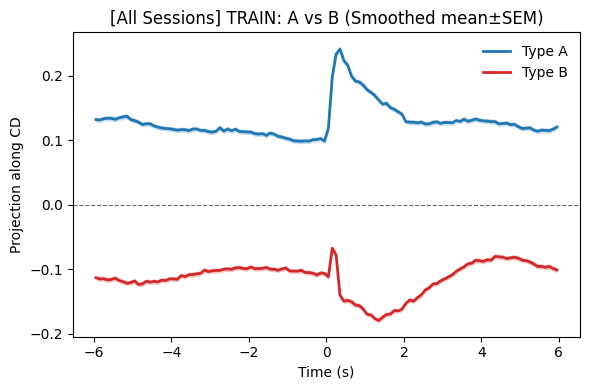

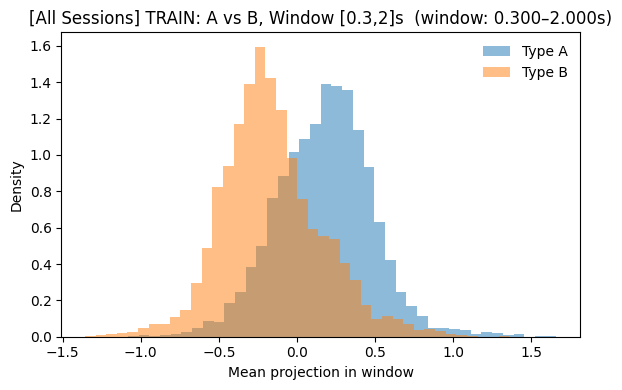

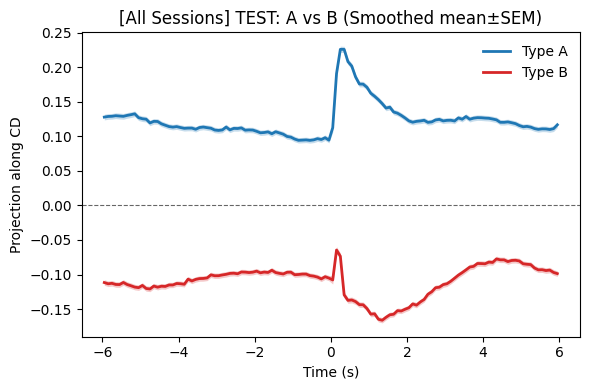

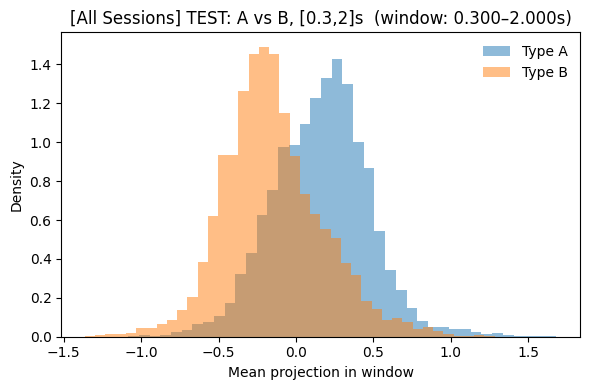

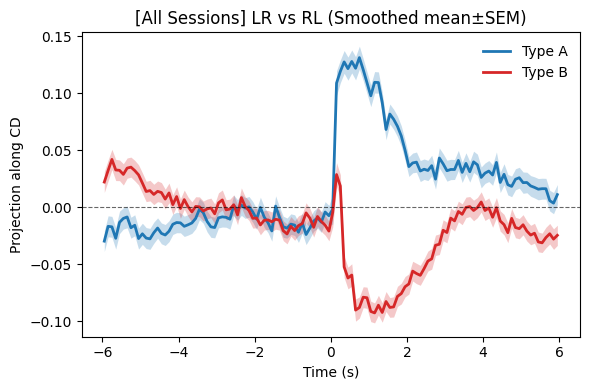

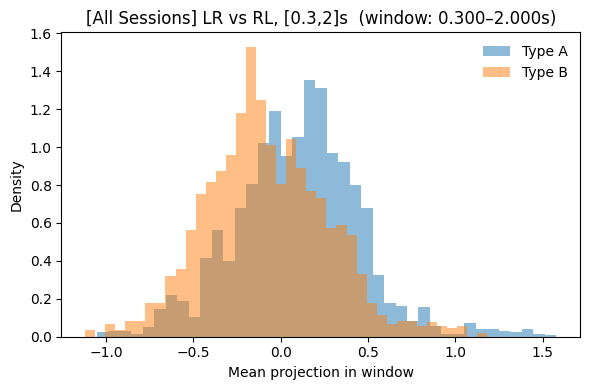

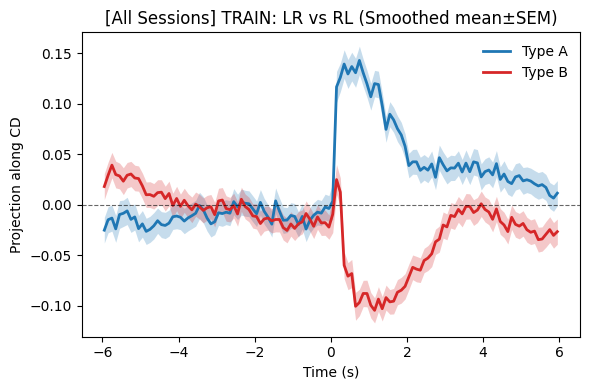

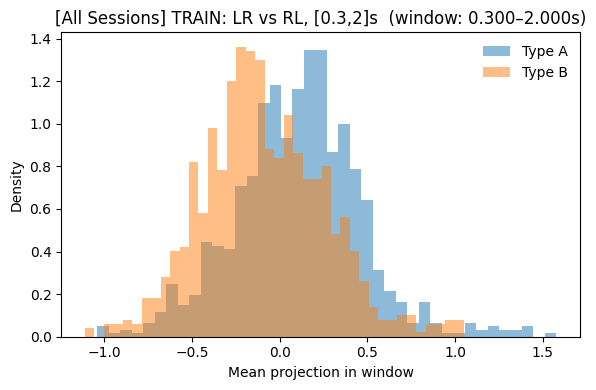

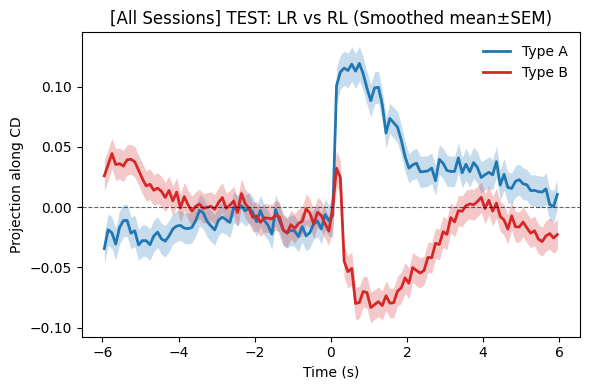

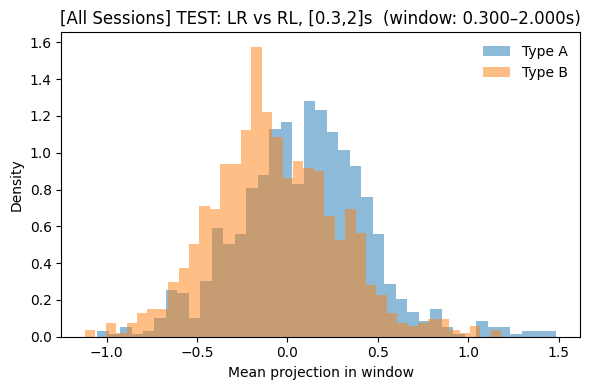

In [17]:
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from general_utils import smart_read_csv

# =========================
# Config
# =========================
base_dir = "/root/capsule/scratch/"
zarr_glob = os.path.join(base_dir, "CD_*.zarr")
distribution_window=(0.3,2)
# Accept multiple filename patterns (enable more if needed)
session_res = [
    #re.compile(r"^CD_(?P<session>.+?)_right_choice_trials_left_choice_trials_timewindow_-1_0\.zarr$"),
    # re.compile(r"^CD_(?P<session>.+?)_rewarded_trials_unrewarded_trials_timewindow_-1_0\.zarr$"),
    re.compile(r"^CD_(?P<session>.+?)_right_choice_trials_left_choice_trials_timewindow_0\.3_2\.zarr$"),
    #re.compile(r"^CD_(?P<session>.+?)_rewarded_trials_unrewarded_trials_timewindow_0\.3_2\.zarr$"),
]

def match_any(patterns, name):
    for pat in patterns:
        m = pat.match(name)
        if m:
            return m
    return None

# =========================
# Helpers
# =========================
def select_traces_by_switch(proj, trial_ids, switch_ids):
    """Return subset of trials whose IDs are in switch_ids."""
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

def cat_or_none(lst):
    """Concatenate only valid 2D arrays; return None if nothing to concat."""
    if not lst:
        return None
    arrs = [a for a in lst if isinstance(a, np.ndarray) and a.ndim == 2 and a.size > 0]
    if not arrs:
        return None
    return np.concatenate(arrs, axis=0)

def concat_ids(lst):
    """Concatenate 1D int arrays; return empty int array if none."""
    if not lst:
        return np.array([], dtype=int)
    arrs = [a for a in lst if isinstance(a, np.ndarray) and a.ndim == 1 and a.size > 0]
    if not arrs:
        return np.array([], dtype=int)
    return np.concatenate(arrs, axis=0)

# =========================
# Aggregators across sessions (switch-filtered categories)
# =========================
cats = {
    "train_A_LR": [], "train_A_RL": [],
    "train_B_LR": [], "train_B_RL": [],
    "test_A_LR":  [], "test_A_RL":  [],
    "test_B_LR":  [], "test_B_RL":  [],
}
trial_ids_cats = {k: [] for k in cats.keys()}   # optional: keep trial IDs
session_tags_cats = {k: [] for k in cats.keys()} # optional: keep session tag per trial row

# =========================
# Aggregators for combined (unfiltered) A/B projections
# =========================
raw_cats = {
    "train_A_all": [],  # all train_A trials across sessions
    "train_B_all": [],
    "test_A_all":  [],
    "test_B_all":  [],
}

summ_rows = []
global_time = None
global_dt = np.nan

# =========================
# Main loop over sessions
# =========================
for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)
    m = match_any(session_res, zname)
    if not m:
        print(f"[skip] filename pattern not recognized: {zname}")
        continue

    # Behavior CSV is named: behavior_summary-<session>.csv
    session_name = m.group("session")
    beh_csv = os.path.join(base_dir, f"behavior_summary-{session_name}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {zname} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print(f"Zarr: {zpath}")
    print(f"CSV : {beh_csv}")

    # --- Load behavior + CD dataset ---
    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zpath, consolidated=False)

    # --- Pull time + projections + IDs ---
    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan
    if global_time is None:
        global_time = time
        global_dt = dt
    else:
        if len(time) == len(global_time) and np.allclose(time, global_time):
            pass
        else:
            print("[warn] time axis differs from previous sessions; concatenation assumes identical length.")

    trial_id_test_A  = np.asarray(ds["trial_id_test_A"].values, dtype=int)
    trial_id_test_B  = np.asarray(ds["trial_id_test_B"].values, dtype=int)
    trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
    trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

    proj_train_A = ds["projection_trace_train_A"].values  # (n_trials, n_time)
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # =========================
    # Append UNFILTERED (combined) projections
    # =========================
    if isinstance(proj_train_A, np.ndarray) and proj_train_A.ndim == 2 and proj_train_A.size > 0:
        raw_cats["train_A_all"].append(proj_train_A)
    if isinstance(proj_train_B, np.ndarray) and proj_train_B.ndim == 2 and proj_train_B.size > 0:
        raw_cats["train_B_all"].append(proj_train_B)
    if isinstance(proj_test_A, np.ndarray) and proj_test_A.ndim == 2 and proj_test_A.size > 0:
        raw_cats["test_A_all"].append(proj_test_A)
    if isinstance(proj_test_B, np.ndarray) and proj_test_B.ndim == 2 and proj_test_B.size > 0:
        raw_cats["test_B_all"].append(proj_test_B)

    # --- Switch trial IDs from behavior (arrays/list-like) ---
    switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)  # L->R switches
    switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)  # R->L switches

    # --- Select subsets by switch type ---
    # Train
    train_A_LR, ids_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
    train_A_RL, ids_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

    train_B_LR, ids_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
    train_B_RL, ids_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

    # Test
    test_A_LR, ids_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
    test_A_RL, ids_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

    test_B_LR, ids_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
    test_B_RL, ids_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

    # --- Append to global (switch-filtered) aggregators ---
    def append_cat(key, X, ids):
        if isinstance(X, np.ndarray) and X.ndim == 2 and X.size > 0:
            cats[key].append(X)
            trial_ids_cats[key].append(ids)
            session_tags_cats[key].extend([session_name] * X.shape[0])

    append_cat("train_A_LR", train_A_LR, ids_train_A_LR)
    append_cat("train_A_RL", train_A_RL, ids_train_A_RL)
    append_cat("train_B_LR", train_B_LR, ids_train_B_LR)
    append_cat("train_B_RL", train_B_RL, ids_train_B_RL)

    append_cat("test_A_LR",  test_A_LR,  ids_test_A_LR)
    append_cat("test_A_RL",  test_A_RL,  ids_test_A_LR)
    append_cat("test_B_LR",  test_B_LR,  ids_test_B_LR)
    append_cat("test_B_RL",  test_B_RL,  ids_test_B_RL)

    # --- Summary printout per session ---
    print("Train A  (LR / RL):", train_A_LR.shape[0], "/", train_A_RL.shape[0])
    print("Train B  (LR / RL):", train_B_LR.shape[0], "/", train_B_RL.shape[0])
    print("Test  A  (LR / RL):", test_A_LR.shape[0],  "/", test_A_RL.shape[0])
    print("Test  B  (LR / RL):", test_B_LR.shape[0],  "/", test_B_RL.shape[0])

    summ_rows.append({
        "session": session_name,
        "train_A_LR_n": int(train_A_LR.shape[0]),
        "train_A_RL_n": int(train_A_RL.shape[0]),
        "train_B_LR_n": int(train_B_LR.shape[0]),
        "train_B_RL_n": int(train_B_RL.shape[0]),
        "test_A_LR_n": int(test_A_LR.shape[0]),
        "test_A_RL_n": int(test_A_RL.shape[0]),
        "test_B_LR_n": int(test_B_LR.shape[0]),
        "test_B_RL_n": int(test_B_RL.shape[0]),
    })

# =========================
# Concatenate across sessions
# =========================
cats_concat = {k: cat_or_none(v) for k, v in cats.items()}
trial_ids_concat = {k: concat_ids(v) for k, v in trial_ids_cats.items()}
session_tags_concat = {k: np.asarray(v, dtype=object) for k, v in session_tags_cats.items()}

# Unfiltered A/B pools
raw_concat = {k: cat_or_none(v) for k, v in raw_cats.items()}

# Also build pooled LR vs RL across A∪B (train and test separately and combined)
pooled = {
    "train_LR": cat_or_none([cats_concat.get("train_A_LR"), cats_concat.get("train_B_LR")]),
    "train_RL": cat_or_none([cats_concat.get("train_A_RL"), cats_concat.get("train_B_RL")]),
    "test_LR":  cat_or_none([cats_concat.get("test_A_LR"),  cats_concat.get("test_B_LR")]),
    "test_RL":  cat_or_none([cats_concat.get("test_A_RL"),  cats_concat.get("test_B_RL")]),
}
pooled["all_LR"] = cat_or_none([pooled["train_LR"], pooled["test_LR"]])
pooled["all_RL"] = cat_or_none([pooled["train_RL"], pooled["test_RL"]])

# =========================
# Save summary CSV
# =========================
if summ_rows:
    summary_df = pd.DataFrame(summ_rows)
    print("\nSummary across sessions:")
    print(summary_df)
    summary_csv = os.path.join(base_dir, "CD_sessions_switch_counts_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"Saved summary: {summary_csv}")
else:
    print("No sessions processed.")

# =========================
# Visualizations (average curves + distributions only)
# Using your existing functions; NO single-trial plots
# =========================
if global_time is None:
    print("[viz] No data aggregated; skip plots.")
else:
    # ---- A) Combined (unfiltered) A vs B ----
    try:
        # TRAIN: mean±SEM
        plot_cd_projection(
            global_time,
            raw_concat["train_A_all"], raw_concat["train_B_all"],
            average=True, sem=True,
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TRAIN: A vs B (Smoothed mean±SEM)"
        )
        # TRAIN: distribution in [-1,0]s
        plot_cd_window_distribution(
            global_time,
            raw_concat["train_A_all"], raw_concat["train_B_all"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TRAIN: A vs B, Window [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TEST: mean±SEM
        plot_cd_projection(
            global_time,
            raw_concat["test_A_all"], raw_concat["test_B_all"],
            average=True, sem=True,
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TEST: A vs B (Smoothed mean±SEM)"
        )
        # TEST: distribution in [-1,0]s
        plot_cd_window_distribution(
            global_time,
            raw_concat["test_A_all"], raw_concat["test_B_all"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TEST: A vs B, [{distribution_window[0]},{distribution_window[1]}]s"
        )
    except NameError:
        print("plot_cd_projection/plot_cd_window_distribution not found; skipping A vs B plots.")

    # ---- B) LR vs RL views: ALL, TRAIN, TEST (mean±SEM + distributions) ----
    try:
        # ALL: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["all_LR"], pooled["all_RL"],
            average=True, sem=True,
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] LR vs RL (Smoothed mean±SEM)"
        )
        # ALL: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["all_LR"], pooled["all_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TRAIN: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["train_LR"], pooled["train_RL"],
            average=True, sem=True,
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TRAIN: LR vs RL (Smoothed mean±SEM)"
        )
        # TRAIN: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["train_LR"], pooled["train_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TRAIN: LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TEST: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["test_LR"], pooled["test_RL"],
            average=True, sem=True,
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TEST: LR vs RL (Smoothed mean±SEM)"
        )
        # TEST: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["test_LR"], pooled["test_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TEST: LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )
    except NameError:
        print("plot_cd_projection/plot_cd_window_distribution not found; skipping LR vs RL plots.")

    plt.show()


[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_timewindow_-1_0.zarr
[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_timewindow_0.3_2.zarr

=== Session: ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25 ===
Zarr: /root/capsule/scratch/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_right_choice_trials_left_choice_trials_timewindow_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary-ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25.csv
[skip] filename pattern not recognized: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_right_choice_trials_left_choice_trials_timewindow_0.3_2.zarr
[skip] filename pattern not recognized: CD_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_rewarded_trials_unrewarded_trials_timewindow_-1_0.zarr
[skip] fi

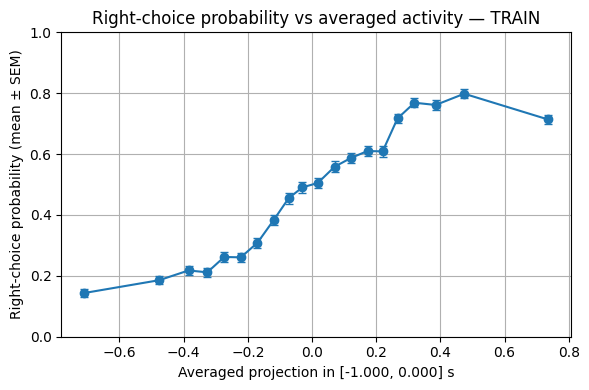

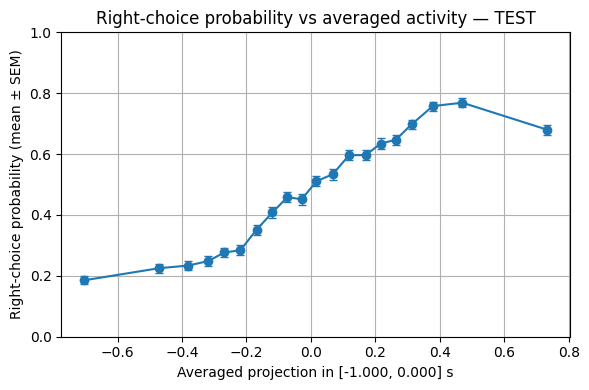

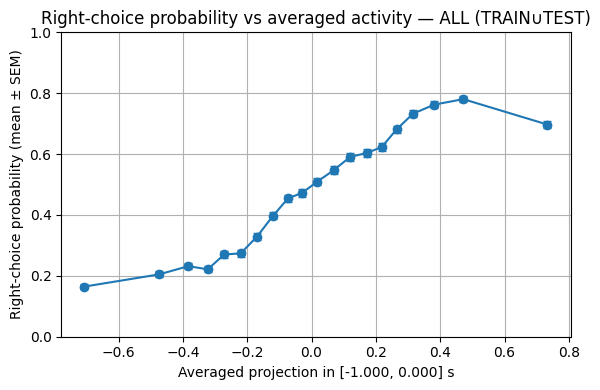

In [23]:
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from general_utils import smart_read_csv

# =========================
# Config
# =========================
base_dir = "/root/capsule/scratch/"
zarr_glob = os.path.join(base_dir, "CD_*.zarr")

# Window over which to average activity for the choice-probability analysis
activity_avg_window = (-1, 0)

# Binning config
binning_method = "quantile"  # "quantile" or "uniform"
n_bins = 20
error_mode = "SEM"            # "SD" or "SEM"

# Accept multiple filename patterns (enable more if needed)
session_res = [
    re.compile(r"^CD_(?P<session>.+?)_right_choice_trials_left_choice_trials_timewindow_-1_0\.zarr$"),
]

def match_any(patterns, name):
    for pat in patterns:
        m = pat.match(name)
        if m:
            return m
    return None

# =========================
# Helpers
# =========================
def build_choice_vector(trial_ids, df_behavior):
    """
    Map per-trial choices aligned to trial_ids.
    Returns float array with 1.0 for right, 0.0 for left, np.nan if neither
    (e.g., no-response / unknown).
    """
    try:
        left_trials = np.asarray(df_behavior["left_choice_trials"][0], dtype=int)
    except KeyError:
        left_trials = np.asarray([], dtype=int)
    try:
        right_trials = np.asarray(df_behavior["right_choice_trials"][0], dtype=int)
    except KeyError:
        right_trials = np.asarray([], dtype=int)

    left_set = set(left_trials.tolist())
    right_set = set(right_trials.tolist())

    choice = np.full(trial_ids.shape[0], np.nan, dtype=float)
    for i, tid in enumerate(trial_ids):
        if tid in right_set:
            choice[i] = 1.0
        elif tid in left_set:
            choice[i] = 0.0
    return choice

def time_window_mask(t, window):
    t0, t1 = window
    if t0 > t1:
        raise ValueError("activity_avg_window must satisfy t0 <= t1")
    return (t >= t0) & (t <= t1)

def bin_activity_and_compute_stats(x, y_right01, n_bins=10, method="quantile", error_mode="SD"):
    """
    x: activity (N,)
    y_right01: 0/1 choices (N,)
    Returns:
        bin_centers, right_prob_mean, right_prob_err, counts, method_used, edges
    """
    x = np.asarray(x)
    y = np.asarray(y_right01)

    if method == "quantile":
        qs = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(x, qs))
        if edges.size < 3:  # pathological (e.g., constant x)
            xmin, xmax = float(np.min(x)), float(np.max(x))
            edges = np.linspace(xmin, xmax, n_bins + 1)
            method_used = "uniform (fallback)"
        else:
            method_used = "quantile"
    else:
        xmin, xmax = float(np.min(x)), float(np.max(x))
        edges = np.linspace(xmin, xmax, n_bins + 1)
        method_used = "uniform"

    inds = np.digitize(x, edges, right=False) - 1
    inds = np.clip(inds, 0, len(edges) - 2)

    means, errs, centers, counts = [], [], [], []
    for b in range(len(edges) - 1):
        mask = inds == b
        cnt = int(np.sum(mask))
        counts.append(cnt)

        if cnt > 0:
            p = float(np.mean(y[mask]))
            if cnt > 1:
                sd = float(np.std(y[mask], ddof=1))
            else:
                sd = 0.0
            err = sd if error_mode == "SD" else (sd / np.sqrt(cnt) if cnt > 0 else np.nan)
            c = float(np.mean(x[mask]))
        else:
            p = np.nan
            err = np.nan
            c = float(0.5 * (edges[b] + edges[b + 1]))

        means.append(p)
        errs.append(err)
        centers.append(c)

    return (
        np.asarray(centers),
        np.asarray(means),
        np.asarray(errs),
        np.asarray(counts),
        method_used,
        np.asarray(edges),
    )

# =========================
# Accumulators for (Y_avg, choice) per split
# =========================
choice_prob_data = {
    "train": {"Yavg": [], "choice": []},
    "test":  {"Yavg": [], "choice": []},
}

global_time = None
global_dt = np.nan

# =========================
# Main loop over sessions
# =========================
for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)
    m = match_any(session_res, zname)
    if not m:
        print(f"[skip] filename pattern not recognized: {zname}")
        continue

    session_name = m.group("session")
    beh_csv = os.path.join(base_dir, f"behavior_summary-{session_name}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {zname} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print(f"Zarr: {zpath}")
    print(f"CSV : {beh_csv}")

    # --- Load behavior + CD dataset ---
    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zarr_path := zpath, consolidated=False)

    # --- Pull time + projections + IDs ---
    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan
    if global_time is None:
        global_time = time
        global_dt = dt
    else:
        if len(time) == len(global_time) and np.allclose(time, global_time):
            pass
        else:
            print("[warn] time axis differs from previous sessions; averaging uses per-file mask.")

    tmask_avg = time_window_mask(time, activity_avg_window)

    # trial IDs
    trial_id_test_A  = np.asarray(ds["trial_id_test_A"].values, dtype=int)
    trial_id_test_B  = np.asarray(ds["trial_id_test_B"].values, dtype=int)
    trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
    trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

    # projection traces
    proj_train_A = ds["projection_trace_train_A"].values  # (n_trials, n_time)
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # Choices aligned to each block
    choice_train_A = build_choice_vector(trial_id_train_A, df)
    choice_train_B = build_choice_vector(trial_id_train_B, df)
    choice_test_A  = build_choice_vector(trial_id_test_A, df)
    choice_test_B  = build_choice_vector(trial_id_test_B, df)

    # Average activity in the window
    def avg_in_window(X):
        if isinstance(X, np.ndarray) and X.ndim == 2 and X.size > 0:
            if not np.any(tmask_avg):
                raise ValueError(f"No time samples in window {activity_avg_window}.")
            return np.nanmean(X[:, tmask_avg], axis=1)
        return np.asarray([], dtype=float)

    Yavg_train_A = avg_in_window(proj_train_A)
    Yavg_train_B = avg_in_window(proj_train_B)
    Yavg_test_A  = avg_in_window(proj_test_A)
    Yavg_test_B  = avg_in_window(proj_test_B)

    # Accumulate TRAIN
    if Yavg_train_A.size:
        valid = ~np.isnan(choice_train_A)
        choice_prob_data["train"]["Yavg"].append(Yavg_train_A[valid])
        choice_prob_data["train"]["choice"].append(choice_train_A[valid])
    if Yavg_train_B.size:
        valid = ~np.isnan(choice_train_B)
        choice_prob_data["train"]["Yavg"].append(Yavg_train_B[valid])
        choice_prob_data["train"]["choice"].append(choice_train_B[valid])

    # Accumulate TEST
    if Yavg_test_A.size:
        valid = ~np.isnan(choice_test_A)
        choice_prob_data["test"]["Yavg"].append(Yavg_test_A[valid])
        choice_prob_data["test"]["choice"].append(choice_test_A[valid])
    if Yavg_test_B.size:
        valid = ~np.isnan(choice_test_B)
        choice_prob_data["test"]["Yavg"].append(Yavg_test_B[valid])
        choice_prob_data["test"]["choice"].append(choice_test_B[valid])

# =========================
# Choice-probability plots only
# =========================
def concat_choice_prob_data(split_key):
    if not choice_prob_data[split_key]["Yavg"]:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    X = np.concatenate(choice_prob_data[split_key]["Yavg"], axis=0)
    Y = np.concatenate(choice_prob_data[split_key]["choice"], axis=0).astype(float)
    return X, Y

X_train, Y_train = concat_choice_prob_data("train")
X_test,  Y_test  = concat_choice_prob_data("test")
X_all = np.concatenate([X_train, X_test], axis=0) if X_train.size or X_test.size else np.asarray([], dtype=float)
Y_all = np.concatenate([Y_train, Y_test], axis=0) if Y_train.size or Y_test.size else np.asarray([], dtype=float)

def plot_choice_prob_vs_activity(X, Y, title_suffix):
    if X.size == 0:
        print(f"[choice-prob] No data for {title_suffix}; skip.")
        return
    centers, means, errs, counts, method_used, edges = bin_activity_and_compute_stats(
        X, Y, n_bins=n_bins, method=binning_method, error_mode=error_mode
    )
    print(f"[choice-prob] {title_suffix}: {method_used} binning, counts={counts.tolist()}")
    fig = plt.figure(figsize=(6, 4))
    plt.errorbar(
        centers, means, yerr=errs,
        fmt="-o", elinewidth=1, capsize=3,
    )
    plt.xlabel(f"Averaged projection in [{activity_avg_window[0]:.3f}, {activity_avg_window[1]:.3f}] s")
    ylabel = "Right-choice probability (mean ± SD)" if error_mode == "SD" else "Right-choice probability (mean ± SEM)"
    plt.ylabel(ylabel)
    plt.title(f"Right-choice probability vs averaged activity — {title_suffix}")
    plt.grid(True, which="both", axis="both")
    plt.ylim(0, 1)  # <-- set y-axis range here
    plt.tight_layout()

plot_choice_prob_vs_activity(X_train, Y_train, "TRAIN")
plot_choice_prob_vs_activity(X_test,  Y_test,  "TEST")
plot_choice_prob_vs_activity(X_all,   Y_all,   "ALL (TRAIN∪TEST)")

plt.show()
